In [ ]:
!pip install transformers
!pip install torch
!pip install torchvision
!pip install matplotlib
!pip install seaborn
!pip install tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 111.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 86.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 96.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [ ]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from transformers import ViTForImageClassification

In [ ]:
# Set random seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
!unzip /content/UCMerced_LandUse.zip

Archive:  /content/UCMerced_LandUse.zip
   creating: UCMerced_LandUse/Images/
   creating: UCMerced_LandUse/Images/agricultural/
  inflating: UCMerced_LandUse/Images/agricultural/agricultural00.tif  
  inflating: UCMerced_LandUse/Images/agricultural/agricultural01.tif  
  inflating: UCMerced_LandUse/Images/agricultural/agricultural02.tif  
  inflating: UCMerced_LandUse/Images/agricultural/agricultural03.tif  
  inflating: UCMerced_LandUse/Images/agricultural/agricultural04.tif  
  inflating: UCMerced_LandUse/Images/agricultural/agricultural05.tif  
  inflating: UCMerced_LandUse/Images/agricultural/agricultural06.tif  
  inflating: UCMerced_LandUse/Images/agricultural/agricultural07.tif  
  inflating: UCMerced_LandUse/Images/agricultural/agricultural08.tif  
  inflating: UCMerced_LandUse/Images/agricultural/agricultural09.tif  
  inflating: UCMerced_LandUse/Images/agricultural/agricultural10.tif  
  inflating: UCMerced_LandUse/Images/agricultural/agricultural11.tif  
  inflating: UCMerc

In [ ]:
data_dir = '/content/UCMerced_LandUse/Images'
NUM_CLASSES = 21  # UCMerced has 21 classes
IMAGE_SIZE = 256   # UCMerced images are 256x256
BATCH_SIZE = 32
NUM_EPOCHS = 30
LEARNING_RATE = 0.001
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cuda


In [ ]:
# Image transformations (adjusted for 256x256 input)
data_transforms = transforms.Compose([
    transforms.Resize(256),  # Original size is 256x256 but 44 images vary
    transforms.CenterCrop(224),  # Standard size for CNNs
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.485, 0.485],  # Custom normalization
                         std=[0.229, 0.229, 0.229])
])

In [ ]:
if not os.path.exists(data_dir):
    print(f"Dataset not found at {data_dir}. Please download UCMerced_LandUse dataset first.")
    exit(1)

dataset = datasets.ImageFolder(root=data_dir, transform=data_transforms)
class_names = dataset.classes
print(f"Classes: {class_names}")

# Split the dataset into training, validation, and test sets
# Setting seed for reproducibility
torch.manual_seed(SEED)
dataset_size = len(dataset)
train_size = int(dataset_size * 0.7)  # 70% for training
val_size = int(dataset_size * 0.15)   # 15% for validation
test_size = dataset_size - train_size - val_size  # 15% for testing

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size]
)

print(f"Training images: {len(train_dataset)}")
print(f"Validation images: {len(val_dataset)}")
print(f"Test images: {len(test_dataset)}")

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

Classes: ['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings', 'chaparral', 'denseresidential', 'forest', 'freeway', 'golfcourse', 'harbor', 'intersection', 'mediumresidential', 'mobilehomepark', 'overpass', 'parkinglot', 'river', 'runway', 'sparseresidential', 'storagetanks', 'tenniscourt']
Training images: 1470
Validation images: 315
Test images: 315


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:
def show_samples(dataloader, class_names, num_samples=10):
    # Get a batch of training data
    dataiter = iter(dataloader)
    images, labels = next(dataiter)

    # Create a grid of images
    plt.figure(figsize=(15, 6))
    for i in range(num_samples):
        # Convert tensor to numpy for visualization
        img = images[i].permute(1, 2, 0).numpy()
        # Unnormalize the image
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)

        plt.subplot(2, 5, i+1)
        plt.imshow(img)
        plt.title(class_names[labels[i].item()])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

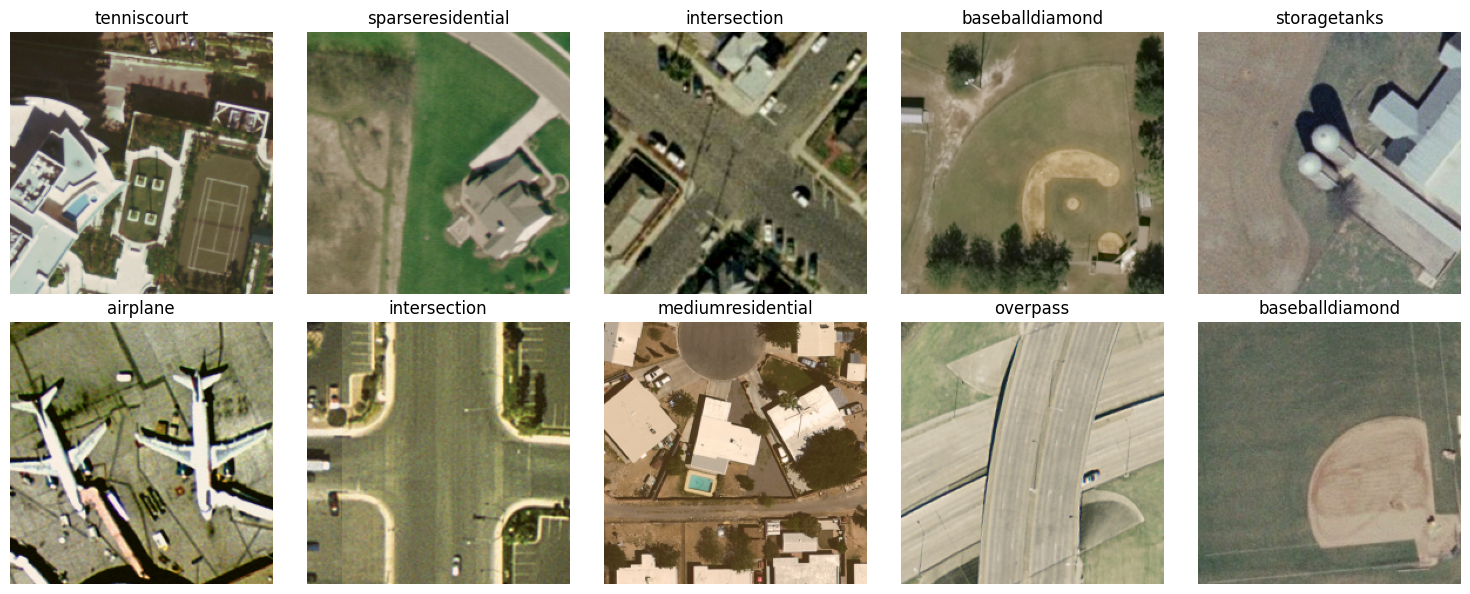

In [ ]:
# Display sample images from training set
show_samples(train_loader, class_names)

In [ ]:
# Define the Vision Transformer model
class ViTModel(nn.Module):
    def __init__(self, num_classes):
        super(ViTModel, self).__init__()
        # Load the pre-trained ViT model
        self.model = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224')
        # Replace classifier with a new one for our number of classes
        self.model.classifier = nn.Linear(in_features=768, out_features=num_classes)

    def forward(self, x):
        return self.model(x).logits # Accessing the logits for classification

In [ ]:
# Initialize model
model = ViTModel(NUM_CLASSES).to(DEVICE)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [ ]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

In [ ]:
# Training and validation functions
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    processed_size = 0

    for inputs, labels in tqdm(dataloader, desc="Training"):
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        processed_size += inputs.size(0)

    epoch_loss = running_loss / processed_size
    epoch_acc = running_corrects.double() / processed_size

    return epoch_loss, epoch_acc

def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    processed_size = 0

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Validating"):
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            # Statistics
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            processed_size += inputs.size(0)

    epoch_loss = running_loss / processed_size
    epoch_acc = running_corrects.double() / processed_size

    return epoch_loss, epoch_acc

In [ ]:
# Training loop
best_val_acc = 0.0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print(f"Starting training for {NUM_EPOCHS} epochs...")

Starting training for 30 epochs...


In [ ]:
for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)

    # Validate
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, DEVICE)

    # Update learning rate
    scheduler.step(val_loss)

    # Update history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc.item())
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc.item())

    epoch_time = time.time() - start_time

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - {epoch_time:.0f}s")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc
        }, 'vit_base_UCMerced_best.pth')
        print(f"Saved new best model with validation accuracy: {val_acc:.4f}")

Validating: 100%|██████████| 10/10 [00:04<00:00,  2.45it/s]


Epoch 1/30 - 50s
Train Loss: 1.5236, Train Acc: 0.5245
Val Loss: 0.7770, Val Acc: 0.7333
Saved new best model with validation accuracy: 0.7333


Validating: 100%|██████████| 10/10 [00:04<00:00,  2.16it/s]


Epoch 2/30 - 54s
Train Loss: 0.8831, Train Acc: 0.7211
Val Loss: 0.7396, Val Acc: 0.7492
Saved new best model with validation accuracy: 0.7492


Validating: 100%|██████████| 10/10 [00:04<00:00,  2.33it/s]


...

Epoch 28/30 - 55s
Train Loss: 0.0002, Train Acc: 1.0000
Val Loss: 0.3360, Val Acc: 0.9175


Validating: 100%|██████████| 10/10 [00:04<00:00,  2.39it/s]


Epoch 29/30 - 55s
Train Loss: 0.0002, Train Acc: 1.0000
Val Loss: 0.3349, Val Acc: 0.9175


Validating: 100%|██████████| 10/10 [00:04<00:00,  2.13it/s]

Epoch 30/30 - 56s
Train Loss: 0.0002, Train Acc: 1.0000
Val Loss: 0.3336, Val Acc: 0.9175


In [ ]:
# Save final model
torch.save({
    'epoch': NUM_EPOCHS,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'val_acc': val_acc
}, 'vit_base_UCMerced_final.pth')

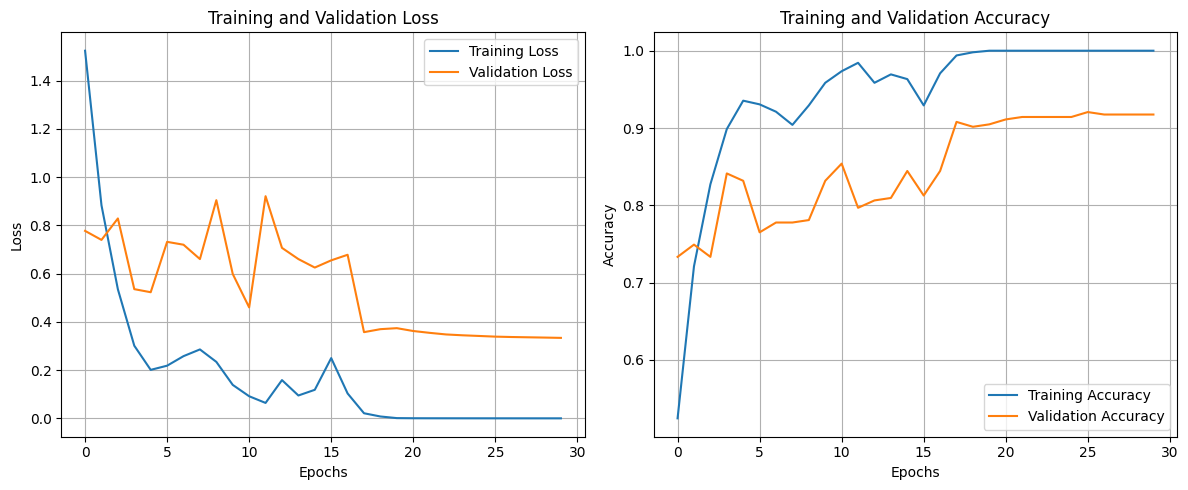

In [ ]:
# Visualize training and validation metrics
plt.figure(figsize=(12, 5))

# Plot training & validation loss
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

# Plot training & validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Training Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('vit_base_UCMerced_metrics.png')
plt.show()

In [ ]:
# Evaluate on the best model
print("Loading best model for final evaluation...")
checkpoint = torch.load('vit_base_UCMerced_best.pth')
model.load_state_dict(checkpoint['model_state_dict'])
best_val_loss, best_val_acc = validate_epoch(model, val_loader, criterion, DEVICE)
print(f"Best model - Val Loss: {best_val_loss:.4f}, Val Acc: {best_val_acc:.4f}")

Loading best model for final evaluation...


Validating: 100%|██████████| 10/10 [00:04<00:00,  2.26it/s]

Best model - Val Loss: 0.3388, Val Acc: 0.9206


In [ ]:
# Evaluate on the test set
print("Evaluating the best model on the test dataset...")
checkpoint = torch.load('vit_base_UCMerced_best.pth')
model.load_state_dict(checkpoint['model_state_dict'])
test_loss, test_acc = validate_epoch(model, test_loader, criterion, DEVICE)
print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

# Calculate class-wise accuracy on test set
class_correct = list(0. for i in range(NUM_CLASSES))
class_total = list(0. for i in range(NUM_CLASSES))

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        c = (predicted == labels).squeeze()
        for i in range(len(labels)):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1

# Print class-wise accuracy
print("\nClass-wise accuracy on test set:")
for i in range(NUM_CLASSES):
    print(f'Accuracy of {class_names[i]}: {100 * class_correct[i] / class_total[i]:.2f}%')

Evaluating the best model on the test dataset...


Validating: 100%|██████████| 10/10 [00:04<00:00,  2.06it/s]

Test Loss: 0.5518, Test Acc: 0.8889



Class-wise accuracy on test set:
Accuracy of agricultural: 94.74%
Accuracy of airplane: 90.91%
Accuracy of baseballdiamond: 93.33%
Accuracy of beach: 100.00%
Accuracy of buildings: 83.33%
Accuracy of chaparral: 100.00%
Accuracy of denseresidential: 90.00%
Accuracy of forest: 100.00%
Accuracy of freeway: 100.00%
Accuracy of golfcourse: 90.91%
Accuracy of harbor: 100.00%
Accuracy of intersection: 85.71%
Accuracy of mediumresidential: 61.90%
Accuracy of mobilehomepark: 87.50%
Accuracy of overpass: 93.33%
Accuracy of parkinglot: 87.50%
Accuracy of river: 100.00%
Accuracy of runway: 100.00%
Accuracy of sparseresidential: 88.89%
Accuracy of storagetanks: 60.00%
Accuracy of tenniscourt: 77.78%


In [ ]:
# Generate confusion matrix
def generate_confusion_matrix(model, dataloader, class_names, device):
    from sklearn.metrics import confusion_matrix
    import seaborn as sns

    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.savefig('vit_base_UCMerced_confusion_matrix.png')
    plt.show()

    return cm

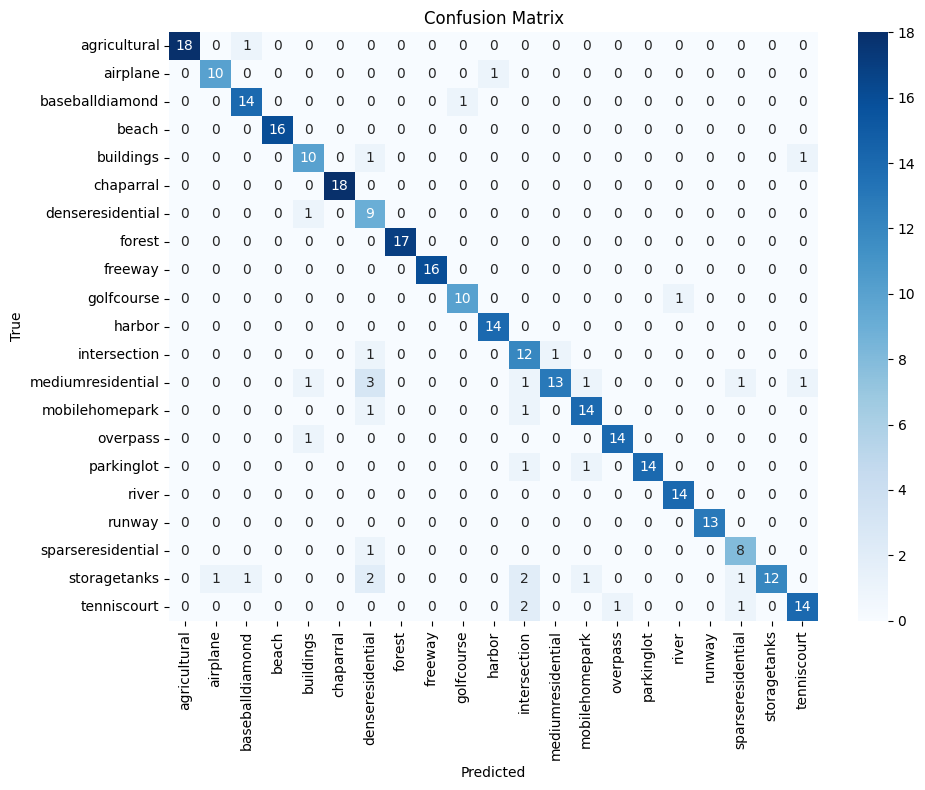

In [ ]:
# Generate confusion matrix on test set
cm = generate_confusion_matrix(model, test_loader, class_names, DEVICE)

In [ ]:
def analyze_confusion_matrix(conf_matrix, class_names):
    """Perform detailed analysis of confusion matrix"""

    # Find most confused pairs
    np.fill_diagonal(conf_matrix, 0)  # zero out the diagonal to focus on errors

    # Get top N confused pairs
    n_top = 5
    confused_pairs = []

    # Iterate until we have n_top pairs or no more errors
    while len(confused_pairs) < n_top and np.max(conf_matrix) > 0:
        # Find max confusion
        max_idx = np.unravel_index(np.argmax(conf_matrix), conf_matrix.shape)
        true_class, pred_class = max_idx

        # Add to list
        confused_pairs.append((
            class_names[true_class],
            class_names[pred_class],
            conf_matrix[true_class, pred_class]
        ))

        # Zero out this pair to find next highest
        conf_matrix[true_class, pred_class] = 0

    # Print analysis
    print("\nTop confused class pairs (true → predicted):")
    for true_class, pred_class, count in confused_pairs:
        print(f"{true_class} → {pred_class}: {count} samples")

    return confused_pairs

In [ ]:
# Analyze confusion matrix
confusion_analysis = analyze_confusion_matrix(cm, class_names)


Top confused class pairs (true → predicted):
mediumresidential → denseresidential: 3 samples
storagetanks → denseresidential: 2 samples
storagetanks → intersection: 2 samples
tenniscourt → intersection: 2 samples
agricultural → baseballdiamond: 1 samples


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


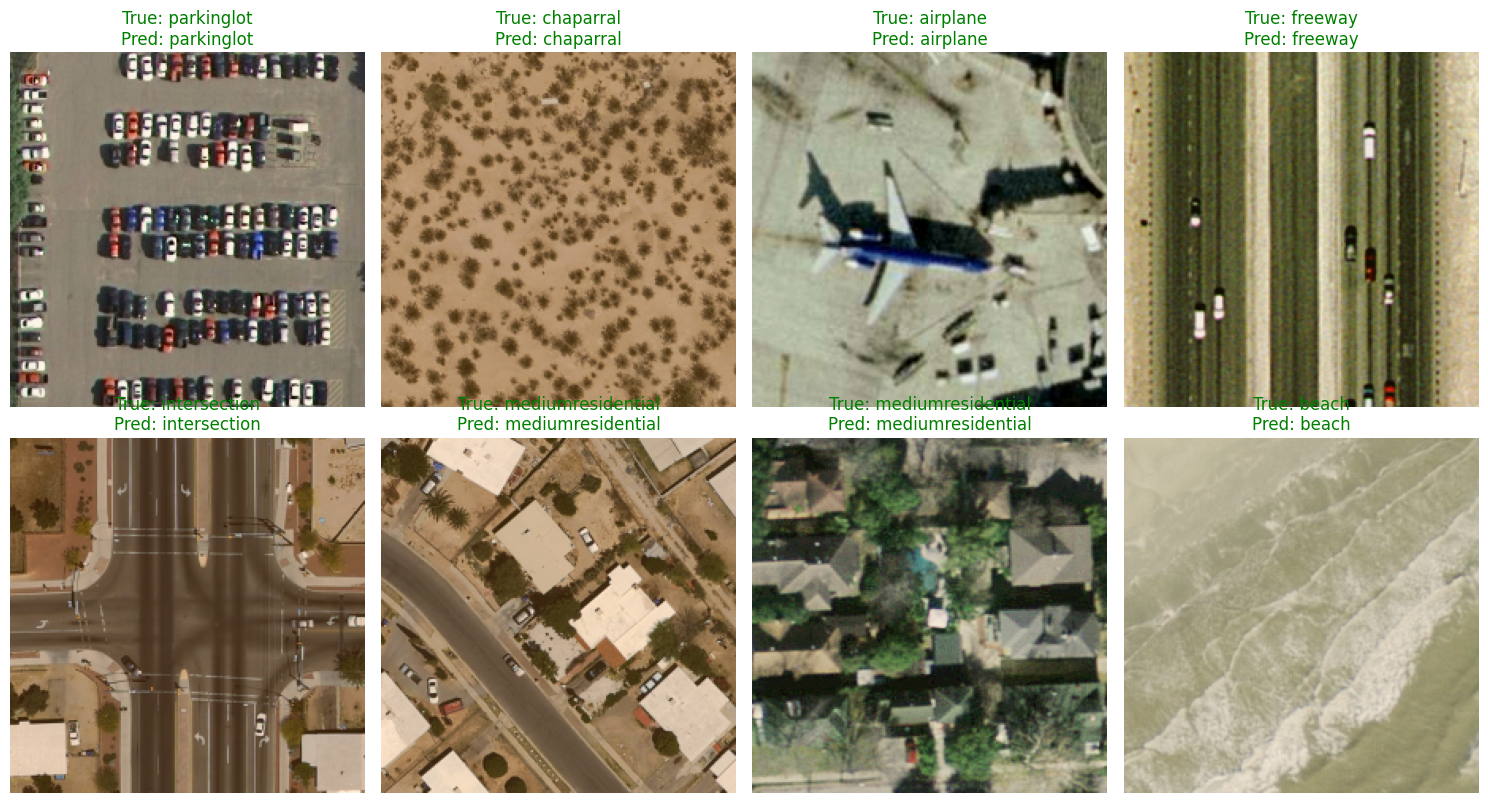

In [ ]:
# Visualize sample predictions
def visualize_predictions(model, data_loader, class_names, device, num_samples=8):
    model.eval()
    images_so_far = 0
    fig = plt.figure(figsize=(15, 8))

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(2, 4, images_so_far)

                # Convert tensor to numpy for visualization
                img = inputs.cpu()[j].permute(1, 2, 0).numpy()
                # Unnormalize the image
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img = std * img + mean
                img = np.clip(img, 0, 1)

                ax.imshow(img)
                true_label = class_names[labels[j].item()]
                pred_label = class_names[preds[j].item()]
                color = 'green' if true_label == pred_label else 'red'
                ax.set_title(f'True: {true_label}\nPred: {pred_label}', color=color)
                ax.axis('off')

                if images_so_far == num_samples:
                    plt.tight_layout()
                    plt.savefig('vit_base_UCMerced_predictions.png')
                    return
        plt.tight_layout()
        plt.savefig('vit_base_UCMerced_predictions.png')
    plt.show()

# Visualize some predictions from the test set
visualize_predictions(model, test_loader, class_names, DEVICE)

In [ ]:
# Add after loading model on test set
import sklearn.metrics as metrics

# Track predictions and labels
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Calculate metrics
accuracy = metrics.accuracy_score(all_labels, all_preds)
precision = metrics.precision_score(all_labels, all_preds, average=None)
recall = metrics.recall_score(all_labels, all_preds, average=None)
f1 = metrics.f1_score(all_labels, all_preds, average=None)
conf_matrix = metrics.confusion_matrix(all_labels, all_preds)

# Overall metrics
print(f"Overall Accuracy: {accuracy:.4f}")
print(f"Overall F1-Score: {metrics.f1_score(all_labels, all_preds, average='weighted'):.4f}")

# Class-wise metrics
print("\nClass-wise Metrics:")
for i in range(NUM_CLASSES):
    print(f"{class_names[i]:20} - Precision: {precision[i]:.4f}, Recall: {recall[i]:.4f}, F1: {f1[i]:.4f}")

Overall Accuracy: 0.8889
Overall F1-Score: 0.8902

Class-wise Metrics:
agricultural         - Precision: 1.0000, Recall: 0.9474, F1: 0.9730
airplane             - Precision: 0.9091, Recall: 0.9091, F1: 0.9091
baseballdiamond      - Precision: 0.8750, Recall: 0.9333, F1: 0.9032
beach                - Precision: 1.0000, Recall: 1.0000, F1: 1.0000
buildings            - Precision: 0.7692, Recall: 0.8333, F1: 0.8000
chaparral            - Precision: 1.0000, Recall: 1.0000, F1: 1.0000
denseresidential     - Precision: 0.5000, Recall: 0.9000, F1: 0.6429
forest               - Precision: 1.0000, Recall: 1.0000, F1: 1.0000
freeway              - Precision: 1.0000, Recall: 1.0000, F1: 1.0000
golfcourse           - Precision: 0.9091, Recall: 0.9091, F1: 0.9091
harbor               - Precision: 0.9333, Recall: 1.0000, F1: 0.9655
intersection         - Precision: 0.6316, Recall: 0.8571, F1: 0.7273
mediumresidential    - Precision: 0.9286, Recall: 0.6190, F1: 0.7429
mobilehomepark       - Precision

In [ ]:
def measure_inference_speed(model, device, input_size=(3, 224, 224), batch_size=1, num_iterations=100):
    model.eval()
    model = model.to(device)

    # Create random input tensor
    dummy_input = torch.randn(batch_size, *input_size, device=device)

    # Warm-up
    with torch.no_grad():
        for _ in range(10):
            _ = model(dummy_input)

    # Measure time
    start_time = time.time()
    with torch.no_grad():
        for _ in range(num_iterations):
            _ = model(dummy_input)
    end_time = time.time()

    elapsed_time = end_time - start_time
    fps = num_iterations * batch_size / elapsed_time
    time_per_image = elapsed_time / (num_iterations * batch_size) * 1000  # ms

    return fps, time_per_image

In [ ]:
# Test on CPU
model.to('cpu')
fps_cpu, time_per_image_cpu = measure_inference_speed(model, 'cpu')
print(f"CPU Inference: {fps_cpu:.2f} FPS ({time_per_image_cpu:.2f} ms per image)")

# Test on GPU (if available)
if torch.cuda.is_available():
    model.to('cuda')
    gpu_name = torch.cuda.get_device_name(0)  # [2][4][6]
    gpu_make = "NVIDIA"
    fps_gpu, time_per_image_gpu = measure_inference_speed(model, 'cuda')

    print(f"GPU Inference ({gpu_make} {gpu_name}): {fps_gpu:.2f} FPS ({time_per_image_gpu:.2f} ms per image)")

    # Calculate speedup
    speedup = fps_gpu / fps_cpu
    print(f"GPU Speedup: {speedup:.2f}x")

CPU Inference: 1.75 FPS (573.01 ms per image)
GPU Inference (NVIDIA Tesla T4): 62.39 FPS (16.03 ms per image)
GPU Speedup: 35.75x


In [ ]:
def measure_memory_usage(model, device, input_size=(3, 224, 224), batch_sizes=[1, 8, 16, 32, 64, 128]):
    """Measure peak memory usage for different batch sizes"""
    model.to(device)
    model.eval()

    if device != 'cuda' or not torch.cuda.is_available():
        print("Memory measurement only available for CUDA devices")
        return

    results = []
    torch.cuda.reset_peak_memory_stats()

    for batch_size in batch_sizes:
        # Clear cache
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

        # Create input
        dummy_input = torch.randn(batch_size, *input_size, device=device)

        # Forward pass
        with torch.no_grad():
            _ = model(dummy_input)
            torch.cuda.synchronize()

        # Get memory stats
        memory_used = torch.cuda.max_memory_allocated() / (1024 ** 2)  # MB
        results.append((batch_size, memory_used))

        print(f"Batch Size: {batch_size}, Peak Memory Usage: {memory_used:.2f} MB")

    # Plot memory usage
    batch_sizes, memory = zip(*results)
    plt.figure(figsize=(10, 6))
    plt.plot(batch_sizes, memory, 'o-')
    plt.xlabel('Batch Size')
    plt.ylabel('Peak Memory Usage (MB)')
    plt.title('VRAM Consumption vs Batch Size')
    plt.grid(True)
    plt.savefig('vit_base_UCMerced_memory_usage.png')
    plt.show()

    return results

Batch Size: 1, Peak Memory Usage: 2332.59 MB
Batch Size: 8, Peak Memory Usage: 2389.13 MB
Batch Size: 16, Peak Memory Usage: 2453.75 MB
Batch Size: 32, Peak Memory Usage: 2583.24 MB
Batch Size: 64, Peak Memory Usage: 2841.96 MB
Batch Size: 128, Peak Memory Usage: 3360.52 MB


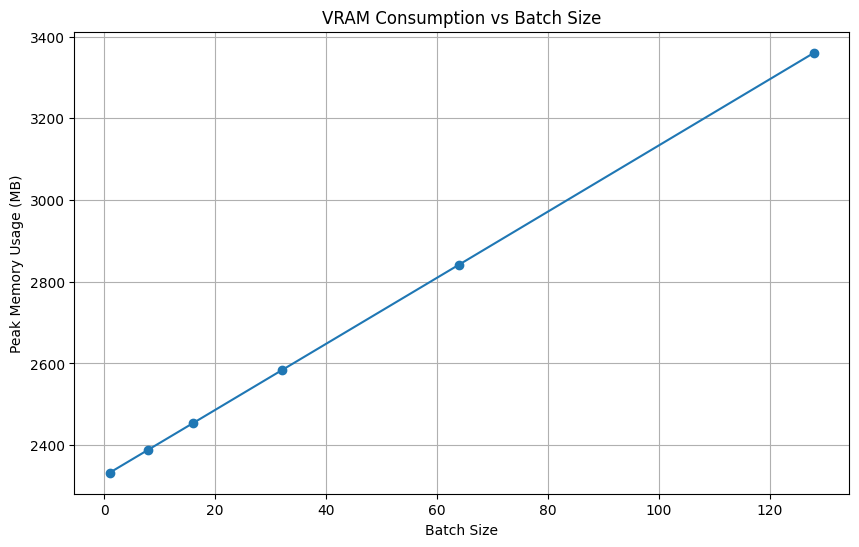

In [ ]:
if torch.cuda.is_available():
    memory_results = measure_memory_usage(model, 'cuda')

In [ ]:
def resolution_ablation_study():
    """Compare model performance across different input resolutions"""
    resolutions = [64, 128, 256]
    results = []

    for res in resolutions:
        print(f"\nTesting resolution: {res}x{res}")

        # Define transforms for this resolution
        transforms_res = transforms.Compose([
            transforms.Resize((res, res)), # Resize to target resolution
            transforms.CenterCrop(224), # Center crop to 224x224
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

        # Create dataset with new resolution
        dataset_res = datasets.ImageFolder(root=data_dir, transform=transforms_res)

        # Split dataset
        torch.manual_seed(SEED)  # For reproducibility
        train_size_res = int(len(dataset_res) * 0.7)
        val_size_res = int(len(dataset_res) * 0.15)
        test_size_res = len(dataset_res) - train_size_res - val_size_res

        _, _, test_dataset_res = random_split(dataset_res, [train_size_res, val_size_res, test_size_res])
        test_loader_res = DataLoader(test_dataset_res, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

        # Create and train a model for this resolution
        # NOTE: For a proper ablation study, you would train a separate model for each resolution
        # Here we're just testing how resolution affects inference on the existing model

        # Adjust model for this resolution (may require architecture changes for very different resolutions)
        if res != 256:
            print(f"Note: Using the same model architecture for {res}x{res} (trained on 224x224)")
            print("A proper study would train a new model for each resolution")

        # Test model on this resolution
        correct = 0
        total = 0

        model.eval()
        with torch.no_grad():
            for inputs, labels in tqdm(test_loader_res, desc=f"Evaluating {res}x{res}"):
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        results.append((res, accuracy))
        print(f"Resolution {res}x{res}: Accuracy = {accuracy:.2f}%")

    # Plot results
    plt.figure(figsize=(10, 6))
    resolutions, accuracies = zip(*results)
    plt.plot(resolutions, accuracies, 'o-')
    plt.xlabel('Resolution')
    plt.ylabel('Accuracy (%)')
    plt.title('Model Accuracy vs. Input Resolution')
    plt.grid(True)
    plt.xticks(resolutions)
    plt.savefig('vit_base_UCMerced_resolution_ablation.png')
    plt.show()

    return results


Testing resolution: 64x64
Note: Using the same model architecture for 64x64 (trained on 224x224)
A proper study would train a new model for each resolution


Evaluating 64x64: 100%|██████████| 10/10 [00:04<00:00,  2.21it/s]


Resolution 64x64: Accuracy = 21.27%

Testing resolution: 128x128
Note: Using the same model architecture for 128x128 (trained on 224x224)
A proper study would train a new model for each resolution


Evaluating 128x128: 100%|██████████| 10/10 [00:04<00:00,  2.08it/s]


Resolution 128x128: Accuracy = 46.35%

Testing resolution: 256x256


Evaluating 256x256: 100%|██████████| 10/10 [00:04<00:00,  2.29it/s]


Resolution 256x256: Accuracy = 84.44%


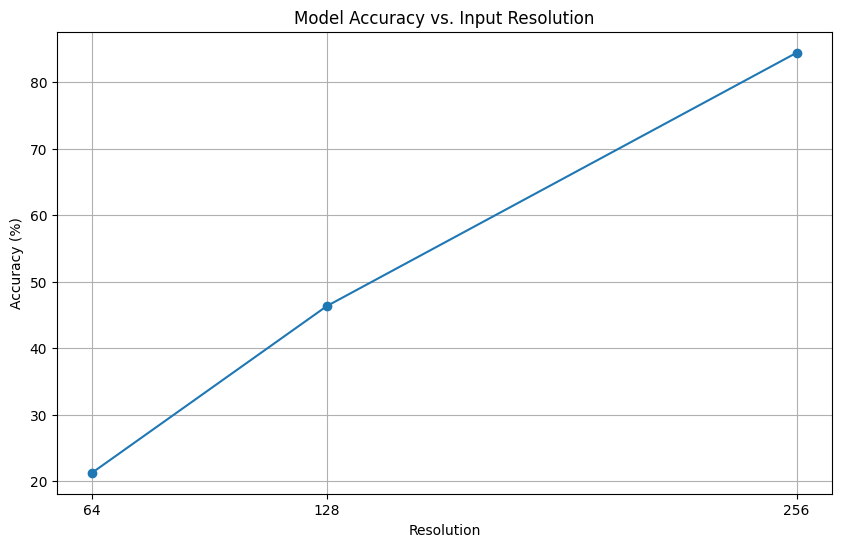

In [ ]:
# Execute ablation study
resolution_results = resolution_ablation_study()

In [ ]:
def statistical_significance_test(runs=5,model_name="vit_base_UCMerced_best.pth"):
    """Run model multiple times and perform statistical significance testing"""
    torch.manual_seed(SEED)

    # Store accuracy for each run
    accuracies = []

    # Create a fresh test loader
    test_loader_stat = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

    for run in range(runs):
        print(f"\nRun {run+1}/{runs}")

        # Reset model
        model_run = ViTModel(NUM_CLASSES).to(DEVICE)

        # Train the model (simplified for brevity)
        # In actual implementation, you would do full training cycle each time
        optimizer_run = optim.Adam(model_run.parameters(), lr=LEARNING_RATE)

        # For demonstration, we'll just load the best model from previous training
        # In a real scenario, you would train from scratch each time
        model_run.load_state_dict(torch.load(model_name)['model_state_dict'])

        # Evaluate
        correct = 0
        total = 0

        model_run.eval()
        with torch.no_grad():
            for inputs, labels in tqdm(test_loader_stat, desc=f"Evaluating run {run+1}"):
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)
                outputs = model_run(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        accuracies.append(accuracy)
        print(f"Run {run+1} Accuracy: {accuracy:.2f}%")

    # Calculate statistics
    mean_acc = np.mean(accuracies)
    std_acc = np.std(accuracies)
    var_acc = np.var(accuracies)

    print("\nStatistical Results:")
    print(f"Mean Accuracy: {mean_acc:.2f}%")
    print(f"Standard Deviation: {std_acc:.2f}")
    print(f"Variance: {var_acc:.2f}")

    # Calculate 95% confidence interval
    from scipy import stats
    confidence = 0.95
    n = len(accuracies)
    std_err = std_acc / np.sqrt(n)
    h = std_err * stats.t.ppf((1 + confidence) / 2, n - 1)

    print(f"{confidence*100}% Confidence Interval: {mean_acc:.2f}% ± {h:.2f}%")
    print(f"Accuracy Range: [{mean_acc-h:.2f}%, {mean_acc+h:.2f}%]")

    return accuracies, mean_acc, std_acc, (mean_acc-h, mean_acc+h)

In [ ]:
# Run statistical significance test
stat_results = statistical_significance_test(model_name="vit_base_UCMerced_best.pth")


Run 1/5


Evaluating run 1: 100%|██████████| 10/10 [00:05<00:00,  1.97it/s]


Run 1 Accuracy: 88.89%

Run 2/5


Evaluating run 2: 100%|██████████| 10/10 [00:04<00:00,  2.17it/s]


Run 2 Accuracy: 88.89%

Run 3/5


...

Run 3 Accuracy: 88.89%

Run 4/5


Evaluating run 4: 100%|██████████| 10/10 [00:04<00:00,  2.09it/s]


Run 4 Accuracy: 88.89%

Run 5/5


Evaluating run 5: 100%|██████████| 10/10 [00:05<00:00,  1.99it/s]


Run 5 Accuracy: 88.89%

Statistical Results:
Mean Accuracy: 88.89%
Standard Deviation: 0.00
Variance: 0.00
95.0% Confidence Interval: 88.89% ± 0.00%
Accuracy Range: [88.89%, 88.89%]
